In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import polars as pl
import datetime

import matplotlib.pyplot as plt
import seaborn as sns

import sys

sys.path.insert(1, "/kaggle/input/styling-library/")
from utils.styling import *

create_notebook_heading(
    title="Discussion Contributor Demographics",
    subtitle="This notebook is a product of collaborative work of several Kagglers, we aim to showcase statistics and demographics of discussion contributors.",
    css="/kaggle/input/styling-library/style/style.html",
    notebook_url="https://www.kaggle.com/luisfrentzen/discussion-contributor-demographics",
    image_url="https://static-cse.canva.com/blob/567558/50stunninglybeautifulgeometricpatternsingraphicdesign.jpg")

# <div class="heading"> Introduction </div>

This notebook is the result of our sessions with fellow Kagglers. We discussed around the topic of discussion demographic, in terms of posting and voting activities. We aim to uncover certain insights that shows different behavior or level of activeness in different progression tiers.

# <div class="heading"> Posts Demographic </div>

In [2]:
PARENT_PATH = "/kaggle/input/meta-kaggle"

In [3]:
forums = pl.read_csv(f"{PARENT_PATH}/ForumMessages.csv")

In [4]:
users = pl.read_csv(f"{PARENT_PATH}/Users.csv")

In [5]:
forums.head()

Id,ForumTopicId,PostUserId,PostDate,ReplyToForumMessageId,Message,Medal,MedalAwardDate
i64,i64,i64,str,str,str,str,str
1,1,478,"""04/28/2010 23:…","""""","""<div>In respon…","""""",""""""
2,2,606,"""04/29/2010 15:…","""""","""Hi, I'm intere…","""""",""""""
3,2,478,"""04/29/2010 15:…","""""","""Tanya,<div><br…","""""",""""""
4,2,368,"""04/29/2010 15:…","""""","""Hi Tanya, <br>…","""""",""""""
14,7,478,"""05/02/2010 14:…","""""","""Now that we ha…","""""",""""""


In [6]:
users.head()

Id,UserName,DisplayName,RegisterDate,PerformanceTier
i64,str,str,str,i64
1,"""kaggleteam""","""Kaggle Team""","""03/24/2011""",5
368,"""antgoldbloom""","""Anthony Goldbl…","""01/20/2010""",2
381,"""iguyon""","""Isabelle""","""01/29/2010""",2
383,"""davidstephan""","""David Stephan""","""02/01/2010""",0
384,"""gabewarren""","""Gabe Warren""","""02/02/2010""",0


In [7]:
users_forum = forums.join(users, left_on="PostUserId", right_on="Id")

In [8]:
users_forum.head()

Id,ForumTopicId,PostUserId,PostDate,ReplyToForumMessageId,Message,Medal,MedalAwardDate,UserName,DisplayName,RegisterDate,PerformanceTier
i64,i64,i64,str,str,str,str,str,str,str,str,i64
4,2,368,"""04/29/2010 15:…","""""","""Hi Tanya, <br>…","""""","""""","""antgoldbloom""","""Anthony Goldbl…","""01/20/2010""",2
68,20,368,"""05/24/2010 15:…","""""","""<span class=""A…","""""","""""","""antgoldbloom""","""Anthony Goldbl…","""01/20/2010""",2
73,20,368,"""05/24/2010 15:…","""""","""Manish, thanks…","""""","""""","""antgoldbloom""","""Anthony Goldbl…","""01/20/2010""",2
74,20,368,"""05/24/2010 15:…","""""","""Just made a ch…","""""","""""","""antgoldbloom""","""Anthony Goldbl…","""01/20/2010""",2
78,20,368,"""05/24/2010 15:…","""""","""<div><span cla…","""""","""""","""antgoldbloom""","""Anthony Goldbl…","""01/20/2010""",2


In [9]:
users_forum = users_forum.with_columns(
    pl.col("PostDate").str.strptime(pl.Date, format="%m/%d/%Y %H:%M:%s")
)

To ensure that the data is relevant, we need to filter for recently active users. We defined recently active users as users that posted at least a content in 2023.

In [10]:
user_forum_filtered = users_forum.filter(
    pl.col("PostDate") >= datetime.datetime(2023, 1, 1)
)

In [11]:
agg_forum_count = user_forum_filtered.groupby(["PostUserId", "UserName", "PerformanceTier"]).agg(
    pl.col("PostDate").max(),
    pl.col("ForumTopicId").count().alias("count")
)

Now we can see each user's total post counted from the beginning of the year.

In [12]:
agg_forum_count.sort("count")

PostUserId,UserName,PerformanceTier,PostDate,count
i64,str,i64,date,u32
937,"""alexandruchirc…",1,2023-06-18,1
1298,"""sgoodfriend""",1,2023-05-03,1
24208,"""stefanistrate""",1,2023-02-27,1
29853,"""raupn85""",0,2023-02-16,1
36141,"""hallayang""",4,2023-03-17,1
38165,"""egyfirst""",2,2023-05-10,1
53333,"""ramirogomez""",1,2023-04-18,1
53342,"""lukasplatinsky…",0,2023-01-25,1
65920,"""issamlaradji""",3,2023-02-06,1


We can now group them by their progression tiers.

In [13]:
agg_tier_forum_density = agg_forum_count.groupby("PerformanceTier").agg(
    pl.col("count").sum().alias("PostCount"),
    pl.col("PostUserId").count().alias("Population")
)

In [14]:
def map_categories(value):
    mapping = {
        0: "Novice",
        1: "Contributor",
        2: "Expert",
        3: "Master",
        4: "Grandmaster",
        5: "Kaggle Team"
    }
    
    return mapping.get(value, "-")

# Apply the mapping function to the DataFrame columns
agg_tier_forum_density = agg_tier_forum_density.with_columns(
    pl.col("PerformanceTier").apply(map_categories)
)

In [15]:
agg_tier_forum_density = agg_tier_forum_density.sort(by=pl.col("PerformanceTier").apply(lambda x: ["Kaggle Team", "Novice", "Contributor", "Expert", "Master", "Grandmaster"].index(x)))

In [16]:
agg_tier_forum_density

PerformanceTier,PostCount,Population
str,u32,u32
"""Kaggle Team""",1146,40
"""Novice""",22027,14751
"""Contributor""",43281,16642
"""Expert""",70254,2354
"""Master""",23000,532
"""Grandmaster""",19250,205


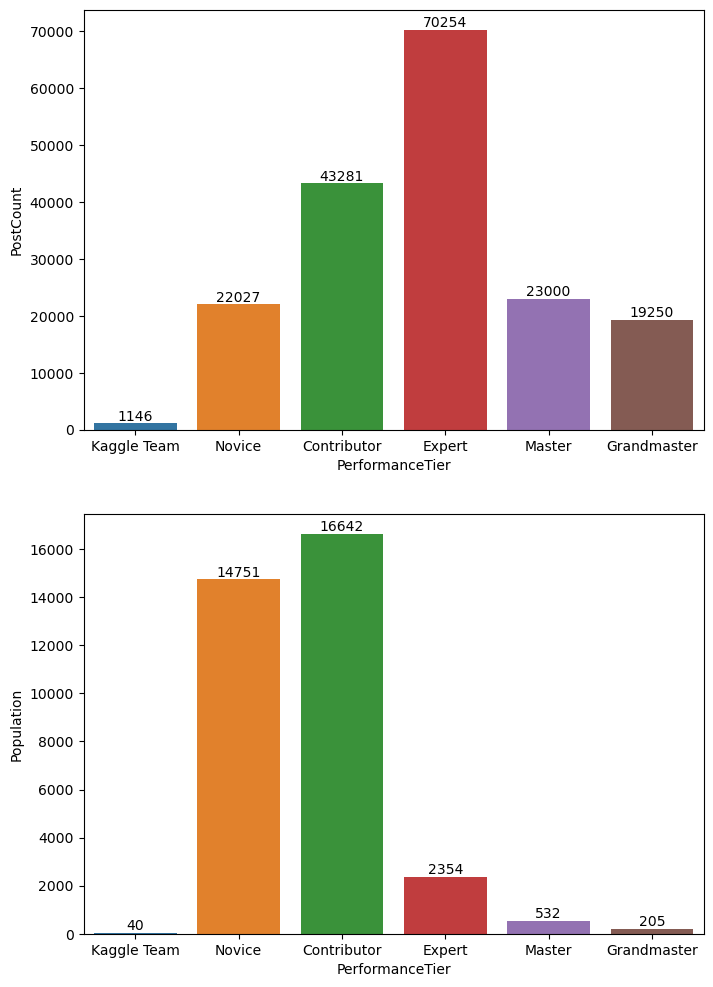

In [17]:
fig, ax = plt.subplots(2, 1, figsize=(8, 12))

g = sns.barplot(y="PostCount", x="PerformanceTier",data=agg_tier_forum_density.to_pandas(), ax=ax[0])
for p in g.patches:
    g.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')

g = sns.barplot(y="Population", x="PerformanceTier",data=agg_tier_forum_density.to_pandas(), ax=ax[1])
for p in g.patches:
    g.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')


By our visualization, we can see that by far Novice and Contributor has the largest population size. But in terms of post count, they are out-posted by the Experts. Experts contribute the most comments/topics posted despite having a moderately sized population. But what about posts per user, if the Experts do have the largest post count of them all does that mean they also have the most average posts per user? Let's find out.

In [18]:
agg_tier_forum_density = agg_tier_forum_density.with_columns(
    MeanPosted = pl.col("PostCount") / pl.col("Population")
)

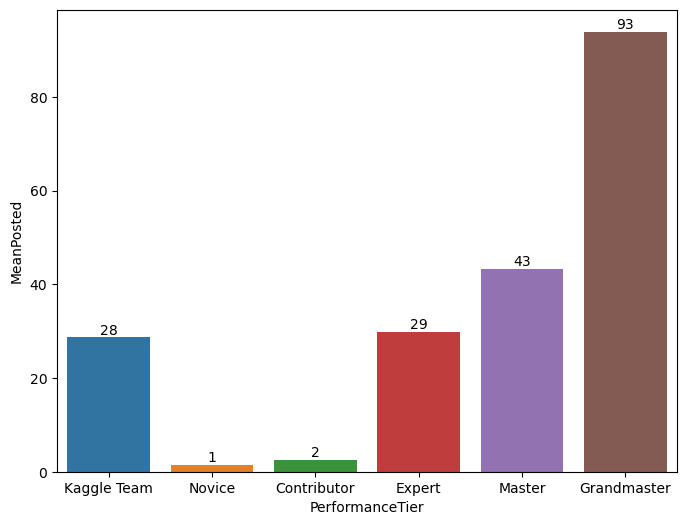

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

g = sns.barplot(y="MeanPosted", x="PerformanceTier",data=agg_tier_forum_density.to_pandas(), ax=ax)
for p in g.patches:
    g.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')

It seems that even though the Experts have the most posts, in terms of average post per user, each Grandmaster on average posted more than 3 times an Expert.

# <div class="heading"> Upvotes Demographic </div>

In [20]:
votes = pl.read_csv(f"{PARENT_PATH}/ForumMessageVotes.csv")

In [21]:
votes

Id,ForumMessageId,FromUserId,ToUserId,VoteDate
i64,i64,i64,i64,str
3372915,1,13067417,478,"""04/13/2023"""
183321,6,307512,638,"""04/06/2017"""
1024883,23,4256072,703,"""12/27/2019"""
1059375,28,417337,368,"""01/21/2020"""
412167,89,1725272,703,"""05/28/2018"""
412168,90,1725272,478,"""05/28/2018"""
513468,224,185772,926,"""10/30/2018"""
133472,352,697221,2246,"""08/26/2016"""
2839598,432,2570595,368,"""06/25/2022"""


In [22]:
votes = votes.with_columns(
    pl.col("VoteDate").str.strptime(pl.Date, format="%m/%d/%Y")
)

In [23]:
votes_filtered = votes.filter(
    pl.col("VoteDate") >= datetime.datetime(2023, 1, 1)
)

In [24]:
votes_filtered

Id,ForumMessageId,FromUserId,ToUserId,VoteDate
i64,i64,i64,i64,date
3372915,1,13067417,478,2023-04-13
3395190,1754,11101616,3256,2023-04-28
3472057,1758,5630844,368,2023-06-11
3466242,2914,3012786,9767,2023-06-07
3385129,3717,548996,2505,2023-04-22
3411566,3717,172860,2505,2023-05-09
3332415,4560,14131258,2505,2023-03-19
3408726,5988,839522,1744,2023-05-07
3386421,6396,14646025,21501,2023-04-23


There is 217698 upvotes given within these 6 months of 2023, it's so great knowing people are backing each other this much this year alone.

In [25]:
users = users.with_columns(
    pl.col("PerformanceTier").apply(map_categories)
)

In [26]:
user_votes = votes_filtered.join(users[["Id", "PerformanceTier"]], left_on="ToUserId", right_on="Id")

In [27]:
user_votes = user_votes.join(users[["Id", "PerformanceTier"]], left_on="FromUserId", right_on="Id")

In [28]:
user_votes.columns = ['Id',
                     'ForumMessageId',
                     'FromUserId',
                     'ToUserId',
                     'VoteDate',
                     'PerformanceTierVoted',
                     'PerformanceTierVoter']

In [29]:
user_votes

Id,ForumMessageId,FromUserId,ToUserId,VoteDate,PerformanceTierVoted,PerformanceTierVoter
i64,i64,i64,i64,date,str,str
3299275,2163239,368,495305,2023-02-28,"""Kaggle Team""","""Expert"""
3318901,1617835,463,582611,2023-03-12,"""Grandmaster""","""Contributor"""
3308148,2161642,463,6430020,2023-03-05,"""Expert""","""Contributor"""
3389812,2234699,767,557674,2023-04-25,"""Contributor""","""Expert"""
3322675,2182076,767,1328185,2023-03-15,"""Grandmaster""","""Expert"""
3311378,2152921,767,1723677,2023-03-07,"""Grandmaster""","""Expert"""
3398912,2241890,767,1723677,2023-05-02,"""Grandmaster""","""Expert"""
3398911,2241911,767,1723677,2023-05-02,"""Grandmaster""","""Expert"""
3295066,2155997,767,1958529,2023-02-26,"""Master""","""Expert"""


In [30]:
agg_user_tier = user_votes.groupby(["ToUserId", "PerformanceTierVoted"]).count().sort("count")

In [31]:
agg_user_tier

ToUserId,PerformanceTierVoted,count
i64,str,u32
5293368,"""Contributor""",1
9438353,"""Contributor""",1
9935012,"""Contributor""",1
12313841,"""Contributor""",1
8645611,"""Contributor""",1
13034312,"""Contributor""",1
622846,"""Contributor""",1
6516,"""Master""",1
6497788,"""Expert""",1


In [32]:
agg_tier = agg_user_tier.groupby("PerformanceTierVoted").mean().sort(by=pl.col("PerformanceTierVoted").apply(lambda x: ["Kaggle Team", "Novice", "Contributor", "Expert", "Master", "Grandmaster"].index(x)))

<Axes: xlabel='PerformanceTierVoted', ylabel='count'>

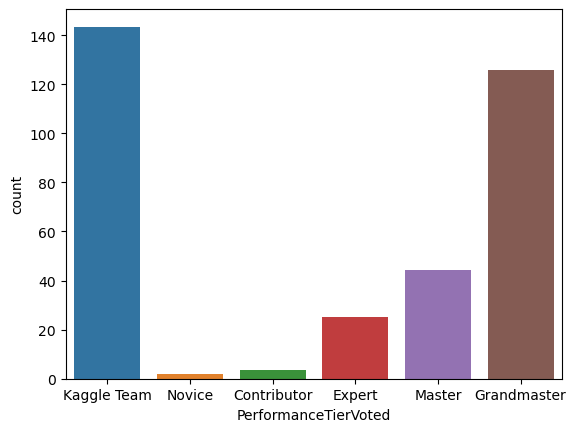

In [33]:
sns.barplot(x="PerformanceTierVoted", y="count", data=agg_tier.to_pandas())

The chart above shows the average votes you get according to what your progression tier is. we can see that the Kaggle Team is being voted the most out of all of us, followed by the grandmasters. It seems normal at a glance and I think this relation can mean a lot of things but I have two guesses which are: 
- that people unconsciously correlate credibility and quality of content by the rank of the poster, thus they tend to upvote people in higher rank/authority more than the others or 
- simply the higher your rank is, the better your writing quality is. That's why they rank higher than the others, because they provide better content which result to more upvotes.

These are two different perspective of how we can look at the problem. I'll need to explore the data more to provide more accountable explanation or proof to this seemingly obvious phenomenon. As always, I'm very open to discussion on the matter.

In [34]:
agg_voter_user_tier = user_votes.groupby(["FromUserId", "PerformanceTierVoter"]).count().sort("count")

In [35]:
agg_voter_user_tier

FromUserId,PerformanceTierVoter,count
i64,str,u32
4126,"""Expert""",1
4183,"""Contributor""",1
4564,"""Contributor""",1
5229,"""Contributor""",1
8723,"""Expert""",1
10803,"""Contributor""",1
16210,"""Contributor""",1
32863,"""Novice""",1
36141,"""Grandmaster""",1


In [36]:
agg_voter_tier = agg_voter_user_tier.groupby("PerformanceTierVoter").mean().sort(by=pl.col("PerformanceTierVoter").apply(lambda x: ["Kaggle Team", "Novice", "Contributor", "Expert", "Master", "Grandmaster"].index(x)))

In [37]:
agg_voter_tier

PerformanceTierVoter,FromUserId,count
str,f64,f64
"""Novice""",1.1345e7,1.660632
"""Contributor""",8.8248e6,4.563566
"""Expert""",5.9662e6,29.203378
"""Master""",3.5055e6,44.405007
"""Grandmaster""",2.3082e6,87.548387


<Axes: xlabel='PerformanceTierVoter', ylabel='count'>

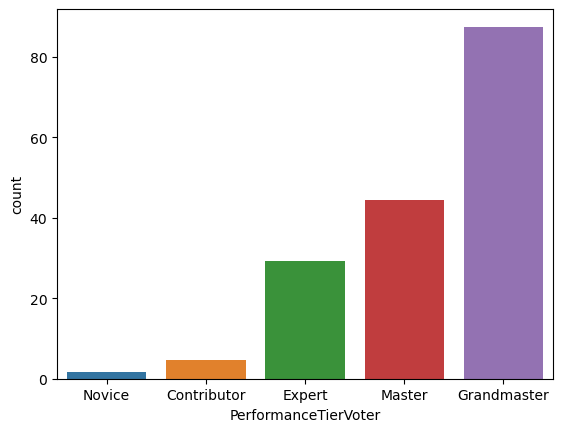

In [38]:
sns.barplot(x="PerformanceTierVoter", y="count", data=agg_voter_tier.to_pandas())

The plot shows the average votes given by each performance tier. Surprisingly this is very similar to the previous chart. One idea that we've discussed as why this is the case is that the more invested you are in the platform (we concluded that the higher rank you have, the more invested you are as ranking up requires a lot of effort) the more active you'll be in the platform. But this also need further investigation, or if you noticed anything wrong with the code, feel free to point it out.

<div class="info"> 
    <div>
        <span class="material-icons i-info">
            info
        </span>
    </div> 
    <div>
        Did you know that there's no record of any upvotes given by the Kaggle Team members? Maybe they're not into the voting game.
    </div>
</div>

# <div class="heading"> Activeness Ratio </div>

Maybe now we can try to see the "activeness" of each the performance tier. How active a tier is in terms of votes given this past 6 months.

In [39]:
voters_id = list(user_votes["FromUserId"].unique())

In [40]:
voters = users.filter(
    pl.col("Id").is_in(voters_id)
)

In [41]:
agg_active_voter = voters.groupby("PerformanceTier").count()

In [42]:
agg_all_voter = users.groupby("PerformanceTier").count()

In [43]:
agg_active_and_voter = agg_active_voter.join(agg_all_voter, left_on="PerformanceTier", right_on="PerformanceTier")

In [44]:
agg_active_and_voter

PerformanceTier,count,count_right
str,u32,u32
"""Expert""",2783,13824
"""Master""",679,2398
"""Grandmaster""",248,437
"""Novice""",16958,13755962
"""Contributor""",11374,210684


In [45]:
agg_voter_ratio = agg_active_and_voter.with_columns(
    ratio = (pl.col("count") / pl.col("count_right")) * 100
).sort(by=pl.col("PerformanceTier").apply(lambda x: ["Kaggle Team", "Novice", "Contributor", "Expert", "Master", "Grandmaster"].index(x)))

In [46]:
agg_voter_ratio

PerformanceTier,count,count_right,ratio
str,u32,u32,f64
"""Novice""",16958,13755962,0.123277
"""Contributor""",11374,210684,5.398606
"""Expert""",2783,13824,20.131655
"""Master""",679,2398,28.315263
"""Grandmaster""",248,437,56.750572


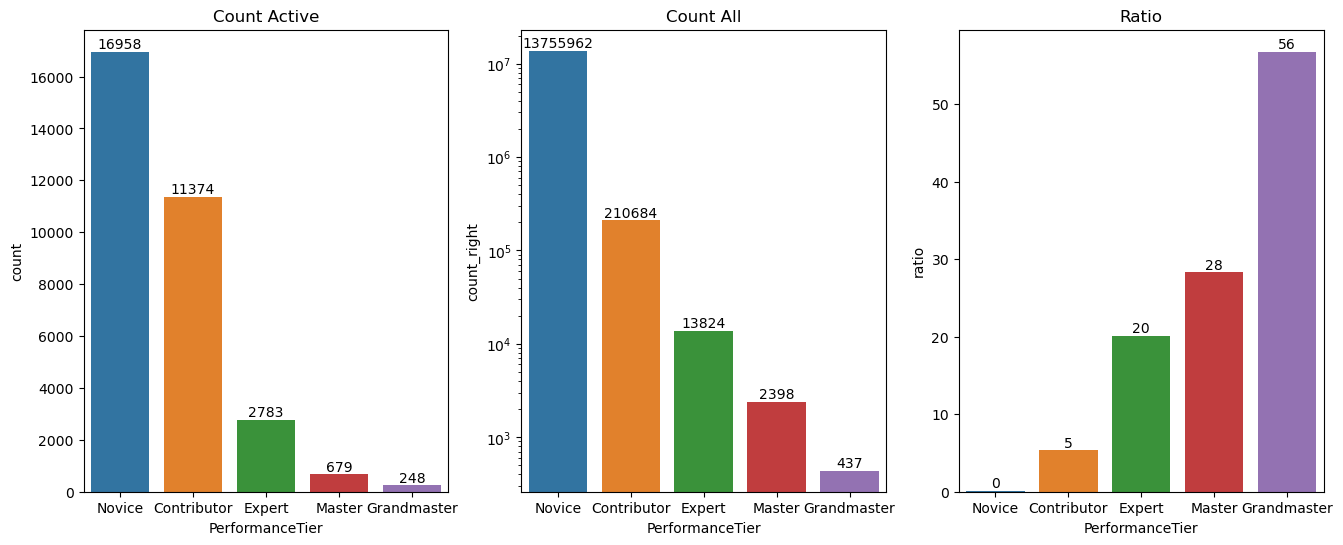

In [47]:
fig, ax = plt.subplots(1, 3, figsize=(16, 6))


g = sns.barplot(y="count", x="PerformanceTier", data=agg_voter_ratio.to_pandas(), ax=ax[0])
_ = g.set_title("Count Active")
for p in g.patches:
    g.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')


g = sns.barplot(y="ratio", x="PerformanceTier", data=agg_voter_ratio.to_pandas(), ax=ax[2])
_ = g.set_title("Ratio")
for p in g.patches:
    g.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')


g = sns.barplot(y="count_right", x="PerformanceTier", data=agg_voter_ratio.to_pandas(), ax=ax[1])
ax[1].set_yscale("log")
_ = g.set_title("Count All")
for p in g.patches:
    g.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

Now we can see that 56% of all grandmasters are actively voting this past 6 months. This supports our previous hypothesis that the more invested you are, the more active you'll be. We can see that there's a lot of contributors, but only 5% of them are actively voting. This chart is very similar to the previous charts.

# <div class="heading"> Closing Sentences </div>

This notebook shows different demographic progression tiers and their contribution to the discussion section for the last 6 months (as of the current writing date, 15/06/2023). It seems that the most of Kagglers that are active in the discussion sections are Experts and they also contribute a lot of topics. While they do have the largest population size, Grandmasters actually contribute the most topics/comments per person. In the second section we explored the demographic of voting activities in the discussion section. There's a lot of similarity here and there with the first section. Grandmasters appear to be the most active, while the Kaggle Team is the most voted of them all. We also came across an idea which describes that the more invested you are in the platform, the more active you'll be. Tell me what do you think of this idea, do you think it is the case?

<hr style="border:0; height:1px; border-top:1px solid rgb(var(--light-gray));">
<div style="width:100%;text-align:center;color:rgb(var(--light-gray))">
    ʕ·͡ᴥ·ʔ Luis Frentzen, 2023
<div>